In [1]:
TSV_DIR = '../data/breseq/tsv_negative_controls_minus_references_minus_control/'
FREQ = 0.15

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams, colors, cm
import matplotlib.patches as mpatches
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

plt.rcParams['svg.fonttype'] = 'none'

In [3]:
import os
import gzip
import numpy as np
import pandas as pd
from Bio import SeqIO
from goatools.obo_parser import GODag
from goatools.goea.go_enrichment_ns import GOEnrichmentStudy

/home/marco/miniforge3/envs/2024_aso_evolution/lib/python3.12/site-packages/goatools/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [4]:
!wget -O ../data/go-basic.obo 'http://purl.obolibrary.org/obo/go/go-basic.obo'

--2025-08-22 12:02:05--  http://purl.obolibrary.org/obo/go/go-basic.obo
Resolving purl.obolibrary.org (purl.obolibrary.org)... 104.18.37.59, 172.64.150.197, 2606:4700:4400::6812:253b, ...
Connecting to purl.obolibrary.org (purl.obolibrary.org)|104.18.37.59|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://current.geneontology.org/ontology/go-basic.obo [following]
--2025-08-22 12:02:05--  https://current.geneontology.org/ontology/go-basic.obo
Resolving current.geneontology.org (current.geneontology.org)... 18.245.31.55, 18.245.31.93, 18.245.31.87, ...
Connecting to current.geneontology.org (current.geneontology.org)|18.245.31.55|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31428837 (30M) [text/obo]
Saving to: ‘../data/go-basic.obo’

../data/go-basic.ob 100%[===================>]  29.97M  2.31MB/s    in 13s     

2025-08-22 12:02:18 (2.39 MB/s) - ‘../data/go-basic.obo’ saved [31428837/31428837]



In [5]:
full_order = [
    'E. coli KFF-scrambled',
    'E. coli (ΔsbmA) KFF-scrambled',
    'E. coli D-KFF-scrambled',
    'E. coli (UPEC) KFF-scrambled',

    'K. pneumoniae KFF-scrambled',
    'S. enterica KFF-scrambled',

    'E. coli RXR-scrambled',
    'P. aeruginosa RXR-scrambled',
]

aso_order = ['KFF-scrambled',
             'D-KFF-scrambled', 'RXR-scrambled']

hue_order = ['E. coli', 'E. coli (ΔsbmA)',
             'E. coli (UPEC)',
             'K. pneumoniae',
             'S. enterica',
             'P. aeruginosa']

tab20 = sns.color_palette('tab20')
tab20c = sns.color_palette('tab20c')

palette = {'E. coli': tab20c[0],
           'E. coli (ΔsbmA)': tab20[6],
           'E. coli (UPEC)': tab20c[12],
           'K. pneumoniae': tab20c[4],
           'S. enterica': tab20c[8],
           'P. aeruginosa': tab20[12]}

In [6]:
tags = {'A': ('RXR-scrambled', 'E. coli'),
        'B': ('D-KFF-scrambled', 'E. coli'),
        'C': ('KFF-scrambled', 'E. coli'),
        'D': ('KFF-scrambled', 'E. coli (ΔsbmA)'),
        'E': ('KFF-scrambled', 'E. coli (UPEC)'),
        'F': ('KFF-scrambled', 'K. pneumoniae'),
        'G': ('KFF-scrambled', 'S. enterica'),
        'H': ('RXR-scrambled', 'P. aeruginosa')}

In [7]:
dsbma = {'E. coli': (.396639, .397859),
         'E. coli (ΔsbmA)': (.396639, .397859),
         'E. coli (UPEC)': (.464110, .465330),
         'K. pneumoniae': (2.935730, 2.936950),
         'S. enterica': (.429845, .431065)}

In [8]:
dacpp = {'E. coli': (1.151615, 1.151851),
         'E. coli (ΔsbmA)': (1.151615, 1.151851),
         'E. coli (UPEC)': (1.142494, 1.142730),
         'K. pneumoniae': (2.044808, 2.045044),
         'S. enterica': (1.236255, 1.236491),
         'P. aeruginosa': (3.324947, 3.325183)}

In [9]:
drpsh = {'E. coli': (3.446152, 3.446545)}

In [10]:
l2name = {}
for tag, fname in zip(['E. coli', 'E. coli (ΔsbmA)',
                       'E. coli (UPEC)', 'K. pneumoniae',
                       'P. aeruginosa', 'S. enterica'],
                      ['ecoli.tsv', 'ecoli.tsv',
                       'upec.tsv', 'klebsiella.tsv',
                       'pseudomonas.tsv', 'salmonella.tsv']):
    l2name[tag] = pd.read_csv(f'../data/references/tsv/{fname}',
                              sep='\t', header=None,
                              index_col=3)[4].to_dict()

In [11]:
obodag = GODag('../data/go-basic.obo')

../data/go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms


In [12]:
cogs = {}
gos = {}
gol = {}
pname = {}
goe = {}
for tag, fname in zip(['E. coli', 'E. coli (ΔsbmA)',
                       'E. coli (UPEC)', 'K. pneumoniae',
                       'P. aeruginosa', 'S. enterica'],
                      ['ecoli.emapper.annotations', 'ecoli.emapper.annotations',
                       'upec.emapper.annotations', 'klebsiella.emapper.annotations',
                       'pseudomonas.emapper.annotations', 'salmonella.emapper.annotations']):
    e = pd.read_csv(f'../data/references/emapper/{fname}.gz',
                    sep='\t', skiprows=4,
                    skipfooter=3, index_col=0, engine='python')
    cogs[tag] = {x[0]: {y.split('@')[0]
                        for y in x[1].values[0].split(',')
                        if y.endswith('@2|Bacteria')}
                 for x in e[['eggNOG_OGs']].iterrows()}
    gos[tag] = {y for x in e['GOs'].values
                  if str(x) != 'nan'
                  for y in x.split(',')}
    gol[tag] = {x[0]: set(x[1].values[0].split(','))
                      if str(x[1].values[0]) != 'nan'
                      else set()
                for x in e[['GOs']].iterrows()}
    pname[tag] = {x[0]: x[1].values[0]
                  for x in e[['Preferred_name']].iterrows()}
    goe[tag] = GOEnrichmentStudy(gol[tag].keys(), gol[tag],
                                 obodag, methods=['fdr_bh'])

for tag in pname:
    for k, v in pname[tag].items():
        if v == '-':
            pname[tag][k] = k


Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
100%  4,073 of  4,073 population items found in association


544 GO IDs NOT FOUND IN ASSOCIATION: GO:0052596 GO:0044661 GO:0051196 GO:0019692 GO:0006057 GO:0036406 GO:0072502 GO:0008759 GO:0070727 GO:0019362 GO:0019577 GO:0022889 GO:0044421 GO:0052857 GO:0031668 GO:0000737 GO:0042374 GO:0044215 GO:0004033 GO:2000112 GO:0071310 GO:0000469 GO:1990507 GO:0043333 GO:0032150 GO:0044463 GO:0097577 GO:0002094 GO:0103046 GO:0000453 GO:0019313 GO:0051691 GO:0001302 GO:0042895 GO:0097056 GO:0046145 GO:0009305 GO:0031328 GO:0015307 GO:0035304 GO:0070469 GO:1901576 GO:0044436 GO:0031230 GO:0043734 GO:0044260 GO:0072503 GO:0031327 GO:0000229 GO:0051272 GO:0031439 GO:0051171 GO:0072505 GO:0045281 GO:0071241 GO:0010676 GO:0044764 GO:0043963 GO:0003867 GO:0046916 GO:0019666 GO:0051187 GO:0009109 GO:0018913 GO:0019419 GO:0031263 GO:0090116 GO:0051801 GO:0018545 GO:0032450 GO:0051188 GO:0033267 GO:0016458 GO:0006734 GO:0014070 GO:0071407 GO:0044437 GO:0032776 GO:0031237 GO:0035998 GO:1901260 GO:1905267 GO:0031331 GO:1901618 GO:0070589 GO:0015002 GO:0034470 GO:000


Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
100%  4,073 of  4,073 population items found in association


544 GO IDs NOT FOUND IN ASSOCIATION: GO:0052596 GO:0044661 GO:0051196 GO:0019692 GO:0006057 GO:0036406 GO:0072502 GO:0008759 GO:0070727 GO:0019362 GO:0019577 GO:0022889 GO:0044421 GO:0052857 GO:0031668 GO:0000737 GO:0042374 GO:0044215 GO:0004033 GO:2000112 GO:0071310 GO:0000469 GO:1990507 GO:0043333 GO:0032150 GO:0044463 GO:0097577 GO:0002094 GO:0103046 GO:0000453 GO:0019313 GO:0051691 GO:0001302 GO:0042895 GO:0097056 GO:0046145 GO:0009305 GO:0031328 GO:0015307 GO:0035304 GO:0070469 GO:1901576 GO:0044436 GO:0031230 GO:0043734 GO:0044260 GO:0072503 GO:0031327 GO:0000229 GO:0051272 GO:0031439 GO:0051171 GO:0072505 GO:0045281 GO:0071241 GO:0010676 GO:0044764 GO:0043963 GO:0003867 GO:0046916 GO:0019666 GO:0051187 GO:0009109 GO:0018913 GO:0019419 GO:0031263 GO:0090116 GO:0051801 GO:0018545 GO:0032450 GO:0051188 GO:0033267 GO:0016458 GO:0006734 GO:0014070 GO:0071407 GO:0044437 GO:0032776 GO:0031237 GO:0035998 GO:1901260 GO:1905267 GO:0031331 GO:1901618 GO:0070589 GO:0015002 GO:0034470 GO:000


Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
100%  4,247 of  4,247 population items found in association


...

510 GO IDs NOT FOUND IN ASSOCIATION: GO:0052596 GO:0051196 GO:0019692 GO:0006057 GO:0036406 GO:0072502 GO:0008759 GO:0070727 GO:0019362 GO:0019577 GO:0022889 GO:0044421 GO:0052857 GO:0031668 GO:0000737 GO:0042374 GO:0044215 GO:0004033 GO:2000112 GO:0071310 GO:0000469 GO:1990507 GO:0043333 GO:0032150 GO:0044463 GO:0097577 GO:0002094 GO:0103046 GO:0000453 GO:0019313 GO:0051691 GO:0001302 GO:0042895 GO:0097056 GO:0046145 GO:0009305 GO:0031328 GO:0015307 GO:0070469 GO:1901576 GO:0044436 GO:0031230 GO:0043734 GO:0044260 GO:0072503 GO:0031327 GO:0000229 GO:0051272 GO:0031439 GO:0051171 GO:0072505 GO:0045281 GO:0071241 GO:0010676 GO:0044764 GO:0043963 GO:0003867 GO:0046916 GO:0019666 GO:0051187 GO:0009109 GO:0018913 GO:0019419 GO:0031263 GO:0090116 GO:0051801 GO:0018545 GO:0032450 GO:0051188 GO:0016458 GO:0006734 GO:0014070 GO:0071407 GO:0044437 GO:0032776 GO:0031237 GO:0035998 GO:1901260 GO:1905267 GO:0031331 GO:1901618 GO:0070589 GO:0015002 GO:0034470 GO:0008852 GO:0031246 GO:0052591 GO:004


Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
100%  5,477 of  5,477 population items found in association


440 GO IDs NOT FOUND IN ASSOCIATION: GO:0044439 GO:0019692 GO:0072502 GO:0008759 GO:0070727 GO:0019362 GO:0044421 GO:0052857 GO:0031668 GO:0042374 GO:0044215 GO:0004033 GO:2000112 GO:0071310 GO:0000469 GO:1990507 GO:0043333 GO:0032150 GO:0044463 GO:0097577 GO:0002094 GO:0000453 GO:0042895 GO:0097056 GO:0046145 GO:0009305 GO:0031328 GO:0035304 GO:0070469 GO:1901576 GO:0044436 GO:0031230 GO:0044260 GO:0072503 GO:0031327 GO:0000229 GO:0051171 GO:0072505 GO:0045281 GO:0071241 GO:0044764 GO:0043963 GO:0003867 GO:0046916 GO:0019666 GO:0051187 GO:0009109 GO:0018913 GO:0019419 GO:0031263 GO:0051801 GO:0051188 GO:0016458 GO:0006734 GO:0014070 GO:0044437 GO:0031237 GO:0035998 GO:1905267 GO:0031331 GO:1901618 GO:0070589 GO:0015002 GO:0034470 GO:0008852 GO:0031246 GO:0052591 GO:0045272 GO:0045282 GO:0102040 GO:0019520 GO:0006561 - GO:0044216 GO:0031235 GO:0018307 GO:0106077 GO:0019008 GO:0010501 GO:0102991 GO:2000372 GO:0030493 GO:0032775 GO:0010243 GO:0051085 GO:0055114 GO:0102250 GO:0030104 GO:0


Load  Ontology Enrichment Analysis ...
Propagating term counts up: is_a
100%  4,542 of  4,542 population items found in association


528 GO IDs NOT FOUND IN ASSOCIATION: GO:0051196 GO:0019692 GO:0006057 GO:0036406 GO:0072502 GO:0008759 GO:0070727 GO:0019362 GO:0019577 GO:0022889 GO:0044421 GO:0052857 GO:0031668 GO:0000737 GO:0042374 GO:0044215 GO:0004033 GO:2000112 GO:0071310 GO:0000469 GO:1990507 GO:0043333 GO:0032150 GO:0044463 GO:0097577 GO:0002094 GO:0103046 GO:0000453 GO:0051691 GO:0042895 GO:0001302 GO:0097056 GO:0046145 GO:0009305 GO:0031328 GO:0015307 GO:0035304 GO:0070469 GO:1901576 GO:0044436 GO:0031230 GO:0043734 GO:0044260 GO:0072503 GO:0031327 GO:0000229 GO:0051272 GO:0031439 GO:0051171 GO:0072505 GO:0045281 GO:0071241 GO:0010676 GO:0044764 GO:0043963 GO:0003867 GO:0046916 GO:0019666 GO:0051187 GO:0009109 GO:0018913 GO:0019419 GO:0031263 GO:0090116 GO:0051801 GO:0018545 GO:0032450 GO:0051188 GO:0033267 GO:0016458 GO:0006734 GO:0015680 GO:0014070 GO:0071407 GO:0044437 GO:0032776 GO:0031237 GO:0035998 GO:1901260 GO:1905267 GO:0031331 GO:1901618 GO:0070589 GO:0015002 GO:0034470 GO:0008852 GO:0031246 GO:005

In [13]:
refs = {}
glen = {}
pseudos = {}
for name, fname in zip(['E. coli',
                        'E. coli (ΔsbmA)',
                        'E. coli (UPEC)',
                        'S. enterica', 'K. pneumoniae',
                        'P. aeruginosa'],
                       ['ecoli.gbk.gz',
                        'ecoli.gbk.gz',
                        'upec.gbk.gz',
                        'salmonella.gbk.gz',
                        'klebsiella.gbk.gz',
                        'pseudomonas.gbk.gz']):
    gpos = {}
    pseudos[name] = set()
    i = 0
    for s in SeqIO.parse(gzip.open(f'../data/references/gbk/{fname}',
                                   'rt'), 'genbank'):
        for f in s.features:
            if 'locus_tag' not in f.qualifiers:
                continue
            l = f.qualifiers['locus_tag'][0]
            if 'pseudo' in f.qualifiers:
                pseudos[name].add(l)
            gpos[l] = ((int(f.location.start) + int(f.location.end)) // 2) + i
        i += len(s)
    glen[name] = i
    refs[name] = gpos

In [14]:
# here we parse the results
# and generate the final table
res = []
for f in os.listdir(TSV_DIR):
    if not f.endswith('.tsv'):
        continue
    fset = '.'.join(f.split('.')[:-1])[0]
    try:
        m = pd.read_csv(f'{TSV_DIR}/{f}', sep='\t')
    except pd.errors.EmptyDataError:
        print(f'{f} is empty')
        continue
    m = m[m['frequency'] >= FREQ].copy()
    m['locus_bed'] = [np.nan if str(x) == '.'
                      else x
                      for x in m['locus_bed'].values]
    m['name_bed'] = [np.nan if str(x) == '.'
                      else x
                      for x in m['name_bed'].values]
    m['set'] = '.'.join(f.split('.')[:-1])[0]
    m['sample'] = '.'.join(f.split('.')[:-1])
    m['aso'] = tags['.'.join(f.split('.')[:-1])[0]][0]
    m['species'] = tags['.'.join(f.split('.')[:-1])[0]][1]
    res.append(m)
m = pd.concat(res)

D01.tsv is empty
E03.tsv is empty


In [15]:
m.groupby('sample')['chrom'].count().sort_values().mean()

np.float64(12.045454545454545)

In [16]:
m.groupby(['set','sample'])['chrom'].count().reset_index().groupby('set')['chrom'].mean().sort_values()

set
D     2.000000
C     2.666667
G     2.666667
A     4.666667
E     5.000000
F     5.333333
H     6.666667
B    61.666667
Name: chrom, dtype: float64

In [17]:
m.groupby(['sample', 'mutation_category'])['chrom'].count().reset_index().pivot_table(index='sample',
                                                                                      columns='mutation_category',
                                                                                      values='chrom',
                                                                                      fill_value=0).mean().sort_values()

mutation_category
snp_nonsense                    0.045455
snp_nonsynonymous|synonymous    0.090909
snp_pseudogene                  0.090909
mobile_element_insertion        0.454545
snp_synonymous                  0.454545
small_indel                     0.681818
snp_nonsynonymous               0.818182
snp_intergenic                  1.000000
large_deletion                  8.409091
dtype: float64

In [18]:
m['species'].unique()

array(['K. pneumoniae', 'E. coli', 'S. enterica', 'E. coli (UPEC)',
       'P. aeruginosa', 'E. coli (ΔsbmA)'], dtype=object)

In [19]:
m['locus'] = [y if str(x) == 'nan' and str(y) != 'nan'
              else x
              for x, y in m[['locus_bed', 'locus_tags_promoter']].values]
names = []
for x, y, z in m[['name_bed', 'genes_promoter', 'locus']].values:
    if str(x) != 'nan':
        names.append(x)
    elif str(x) == 'nan' and str(y) != 'nan':
        names.append(y)
    else:
        names.append(z)
m['locus_pos'] = [refs[species].get(x, (p1 + p2) // 2)
                  for p1, p2, species, x in m[['position_start',
                                               'position_end',
                                               'species', 'locus']].values]
m['name'] = names
m['og'] = [pname[tag].get(x, x)
           for tag, x in m[['species', 'locus']].values]
m['pseudogene'] = [True if x in pseudos[y]
                   else False
                   for x, y in m[['locus', 'species']].values]
m = m.reset_index(drop=True)

In [20]:
m.columns

Index(['chrom', 'position_start', 'position_end', 'mutation_category',
       'aa_new_seq', 'aa_position', 'aa_ref_seq', 'codon_new_seq',
       'codon_number', 'codon_position', 'codon_ref_seq', 'freq', 'frequency',
       'gene_name', 'gene_position', 'gene_product', 'gene_strand',
       'genes_inactivated', 'genes_overlapping', 'genes_promoter', 'locus_tag',
       'locus_tags_inactivated', 'locus_tags_overlapping',
       'locus_tags_promoter', 'mtype', 'pos', 'ref_seq', 'repeat_length',
       'repeat_new_copies', 'repeat_ref_copies', 'repeat_seq', 'sample',
       'snp_type', 'transl_table', 'chrom_bed', 'start_bed', 'end_bed',
       'locus_bed', 'name_bed', 'set', 'aso', 'species', 'repeat_size',
       'insert_position', 'mediated', 'locus', 'locus_pos', 'name', 'og',
       'pseudogene'],
      dtype='object')

In [21]:
cols = ['set', 'aso', 'species',
        'sample',
        'chrom', 'position_start', 'position_end', 'mutation_category',
        'frequency',
        'locus', 'name', 'og', 'pseudogene',
        
        'aa_new_seq', 'aa_position', 'aa_ref_seq', 'codon_new_seq',
        'codon_number', 'codon_position', 'codon_ref_seq',
        'gene_name', 'gene_position', 'gene_product', 'gene_strand',
        'genes_inactivated', 'genes_overlapping', 'genes_promoter',
        'insert_position', 'locus_tag', 'locus_tags_inactivated',
        'locus_tags_overlapping', 'locus_tags_promoter',
        'ref_seq',
        'snp_type', 'transl_table',
        'repeat_size', 'mediated', 'repeat_length',
        'repeat_new_copies', 'repeat_ref_copies', 'repeat_seq']

In [22]:
m[cols].sort_values(['set', 'sample',
                     'chrom', 'position_start']).to_csv('all_mutations_neg_control.tsv.gz',
                                                        sep='\t',
                                                        index=False)

In [23]:
# quickly check which orthologous group
# is most frequently mutated
m.groupby(['aso', 'species', 'og'])['sample'].nunique().sort_values()

aso              species        og           
D-KFF-scrambled  E. coli        cheR             1
                                cheY             1
                                cheZ             1
                                cheB             1
                                fimE             1
                                                ..
KFF-scrambled    K. pneumoniae  wcaJ             3
                                IT767_RS00020    3
                 E. coli        fimE             3
RXR-scrambled    P. aeruginosa  PA0718           3
                                PA0727           3
Name: sample, Length: 145, dtype: int64

In [24]:
m['mutation_category'].unique()

array(['snp_intergenic', 'small_indel', 'snp_synonymous',
       'mobile_element_insertion', 'snp_nonsynonymous', 'snp_pseudogene',
       'large_deletion', 'snp_nonsense', 'snp_nonsynonymous|synonymous'],
      dtype=object)

In [25]:
len(m['sample'].unique())

22

In [26]:
# here for plotting purposes
# I am assigning a number to each mutation type
t2i = {
    'snp_nonsynonymous': 0,
    'snp_nonsynonymous|synonymous':0,
    
    'snp_nonsense': 1,
    
    'small_indel': 2,

    'snp_noncoding': 3,
    
    'snp_intergenic': 4,
    'snp_pseudogene': 4,
    
    'snp_synonymous': 5,
    
    'large_insertion': 6,
    'large_deletion': 6,
    'large_substitution': 6,
    
    'mobile_element_insertion': 7,

    'mobile_element_insertion_JC': 8,
}

In [27]:
# and here the corresponding colors
colors = [
# 0 snp_nonsynonymous
    'xkcd:pale red',
# 1 snp_nonsense
    'xkcd:bright red',
# 2 small_indel
    'xkcd:rust',
# 3 snp_noncoding
    'xkcd:aqua green',
# 4 snp_intergenic
    'xkcd:grey',
# 5 snp_synonymous
    'xkcd:steel',
# 6 large_deletion
    'xkcd:neon purple',
# 7 mobile_element_insertion
    'xkcd:violet',
# 8 mobile_element_insertion
    'xkcd:violet red',
]
cmap = LinearSegmentedColormap.from_list('Custom', colors, len(colors))
cmap.set_under('xkcd:light grey')

In [28]:
# adding the numerical encoding for each mutation type
m['ntype'] = [t2i.get(x, -1) for x in m['mutation_category'].values]

In [29]:
# small function to account for the fact that a single
# gene in a strain might have multiple mutations
# this function picks the right number for each gene
# based on a priority list:
# mutations with higher likelihood to be deleterious
# to the function of the gene are prioritized
def pick_mtype(v):
    values = v.values
    if 6 in values or 7 in values:
        return 7
    elif 8 in values:
        return 8
    elif 1 in values:
        return 1
    elif 0 in values:
        return 0
    elif 2 in values:
        return 2
    elif 3 in values:
        return 3
    elif 4 in values:
        return 4
    elif 5 in values:
        return 5
    elif -1 in values:
        return -1
    else:
        raise ValueError(f'missing case for {str(sorted(set(values)))}')

In [30]:
m[(~m['ntype'].isin([4, 5])) &
  (~m['pseudogene'])]['mutation_category'].unique()

array(['small_indel', 'mobile_element_insertion', 'snp_nonsynonymous',
       'large_deletion', 'snp_nonsense', 'snp_nonsynonymous|synonymous'],
      dtype=object)

In [31]:
res = []
cname = {}
# also filter out small indels in intergenic regions
nidx = [x for x, row in m[m['ntype'] == 2].iterrows()
        if 'intergenic' in str(row['gene_position'])]
t = m.loc[m.index.difference(nidx)]
#
for _, row in t[(~t['ntype'].isin([4, 5])) &
                (~t['pseudogene'])].iterrows():
    dset = row['set']
    tag = row['species']
    aso = row['aso']
    sample = row['sample']
    mtype = row['mutation_category']
    ntype = row['ntype']
    locus = row['locus']
    name = row['name']
    og = row['og']
    for cog in cogs[tag].get(locus, [locus]):
        cname[cog] = cname.get(cog, {})
        cname[cog][og] = cname[cog].get(og, 0)
        cname[cog][og] += 1
        res.append([dset, tag, aso, sample, mtype,
                    ntype, locus, name, og, cog])
cname = {k: sorted(v, key=lambda x: v[x])[-1]
         for k, v in cname.items()}
c = pd.DataFrame(res,
                 columns=['set', 'species', 'aso',
                          'sample', 'mutation_category',
                          'ntype', 'locus', 'name', 'og',
                          'cog'])
c = c.dropna()
c['dname'] = [cname[x] if x != cname[x]
              else x
              for x in c['cog'].values]
c['dname'] = [l2name[y].get(x, x) if l2name[y].get(x, x) != '.'
              else x
              for x, y in c[['dname', 'species']].values]

In [32]:
cbak = c.copy()

In [33]:
c = c.groupby(['species', 'aso', 'dname'])['sample'].nunique().reset_index()

In [34]:
ch = c.pivot_table(index='dname', columns=['aso', 'species'],
                   values='sample', aggfunc='max',
                   fill_value=0)

In [35]:
ch = ch.loc[ch.T.sum().sort_values().index]

In [36]:
c = ch.unstack().reset_index()

In [37]:
c

,aso,species,dname,0
0,D-KFF-scrambled,E. coli,ECP_RS10570,0
1,D-KFF-scrambled,E. coli,cadC,0
2,D-KFF-scrambled,E. coli,crp,0
3,D-KFF-scrambled,E. coli,csrA,0
4,D-KFF-scrambled,E. coli,cpxA,0
...,...,...,...,...
827,RXR-scrambled,P. aeruginosa,motB,0
828,RXR-scrambled,P. aeruginosa,yhjD,0
829,RXR-scrambled,P. aeruginosa,wcaJ,0
830,RXR-scrambled,P. aeruginosa,flhC,0


In [38]:
cc = c.groupby(['dname', 'aso'])[0].max().sort_values().reset_index()

In [39]:
m.groupby(['set', 'species', 'aso'])['sample'].nunique()

set  species          aso            
A    E. coli          RXR-scrambled      3
B    E. coli          D-KFF-scrambled    3
C    E. coli          KFF-scrambled      3
D    E. coli (ΔsbmA)  KFF-scrambled      2
E    E. coli (UPEC)   KFF-scrambled      2
F    K. pneumoniae    KFF-scrambled      3
G    S. enterica      KFF-scrambled      3
H    P. aeruginosa    RXR-scrambled      3
Name: sample, dtype: int64

In [40]:
aso_order

['KFF-scrambled', 'D-KFF-scrambled', 'RXR-scrambled']

/home/marco/miniforge3/envs/2024_aso_evolution/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


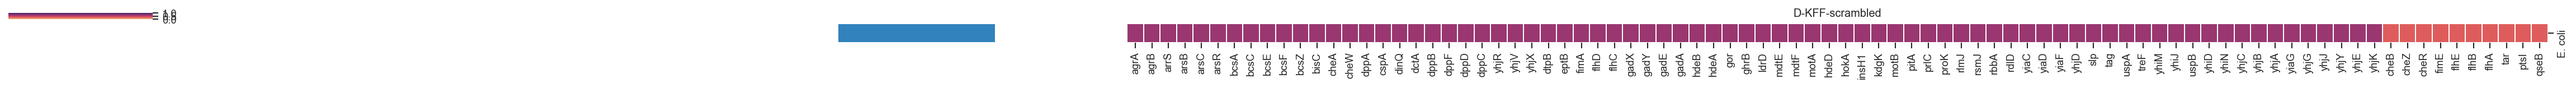

In [41]:
t = c[(c['aso'] == 'D-KFF-scrambled') &
      (c['dname'].isin(cc[(cc['aso'] == 'D-KFF-scrambled') &
                          (cc[0] > 0)]['dname'].values))].copy()
t[0] = t[0] / 3
tt = t.pivot_table(index='species',
              columns='dname', values=0)

tt = tt[tt.mean().sort_values(ascending=False).index]

cmap = plt.get_cmap('flare').copy()
cmap.set_under('xkcd:light grey')
cm = sns.clustermap(tt.loc[hue_order[0:1]],
               cmap=cmap,
               vmin=1E-100 / 10, vmax=1,
               row_cluster=False,
               col_cluster=False,
               figsize=(.4 * tt.loc[hue_order[0:1]].shape[1], .4 * tt.loc[hue_order[0:1]].shape[0]),
               xticklabels=True,
               yticklabels=True,
               linewidths=0.1,
               row_colors=[palette[x] for x in hue_order[0:1]],
               colors_ratio=0.08)

cm.ax_heatmap.set_title('D-KFF-scrambled')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_ylabel('')

plt.savefig('D-KFF-scrambled_frequency_hm.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('D-KFF-scrambled_frequency_hm.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);

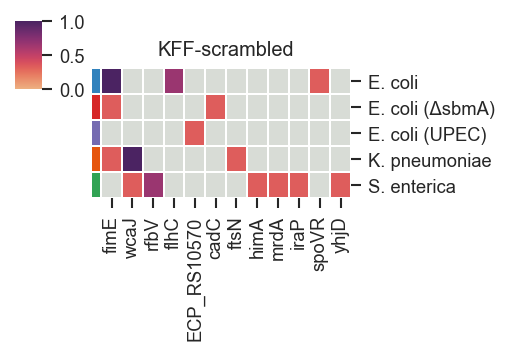

In [42]:
t = c[(c['aso'] == 'KFF-scrambled') &
      (c['dname'].isin(cc[(cc['aso'] == 'KFF-scrambled') &
                          (cc[0] > 0)]['dname'].values))].copy()
t[0] = t[0] / 3
tt = t.pivot_table(index='species',
              columns='dname', values=0)

tt = tt[tt.mean().sort_values(ascending=False).index]

tt = tt.rename(columns={'16S ribosomal RNA': '16S rRNA',
                        'mexT': 'COG0583'})

cmap = plt.get_cmap('flare').copy()
cmap.set_under('xkcd:light grey')
cm = sns.clustermap(tt.loc[hue_order[:-1]],
               cmap=cmap,
               vmin=1E-100 / 10, vmax=1,
               row_cluster=False,
               col_cluster=False,
               figsize=(.3 * tt.loc[hue_order[:-1]].shape[1], .5 * tt.loc[hue_order[:-1]].shape[0]),
               xticklabels=True,
               yticklabels=True,
               linewidths=0.1,
               row_colors=[palette[x] for x in hue_order[:-1]],
               # colors_ratio=0.05
                   )

cm.ax_heatmap.set_title('KFF-scrambled')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_ylabel('')

plt.savefig('KFF-scrambled_frequency_hm_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('KFF-scrambled_frequency_hm_all.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);

/home/marco/miniforge3/envs/2024_aso_evolution/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


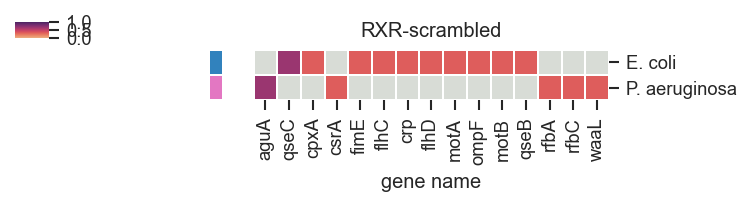

In [43]:
t = c[(c['aso'] == 'RXR-scrambled') &
      (c['dname'].isin(cc[(cc['aso'] == 'RXR-scrambled') &
                          (cc[0] > 0)]['dname'].values))].copy()
t[0] = t[0] / 3
tt = t.pivot_table(index='species',
              columns='dname', values=0)

tt = tt[tt.mean().sort_values(ascending=False).index]

tt = tt.rename(columns={'16S ribosomal RNA': '16S rRNA',
                        'mexT': 'COG0583'})

cmap = plt.get_cmap('flare').copy()
cmap.set_under('xkcd:light grey')
cm = sns.clustermap(tt.loc[[hue_order[0], hue_order[-1]]],
               cmap=cmap,
               vmin=1E-100 / 10, vmax=1,
               row_cluster=False,
               col_cluster=False,
               figsize=(.3 * tt.loc[[hue_order[0], hue_order[-1]]].shape[1],
                        .3 * tt.loc[[hue_order[0], hue_order[-1]]].shape[0]),
               xticklabels=True,
               yticklabels=True,
               linewidths=0.1,
               row_colors=[palette[x] for x in [hue_order[0], hue_order[-1]]],
               # colors_ratio=0.05
                   )

cm.ax_heatmap.set_title('RXR-scrambled')
cm.ax_heatmap.set_xlabel('gene name')
cm.ax_heatmap.set_ylabel('')

plt.savefig('RXR-scrambled_frequency_hm_all.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True)
plt.savefig('RXR-scrambled_frequency_hm_all.svg',
            dpi=300,
            bbox_inches='tight',
            transparent=True);

In [44]:
# also filter out small indels in intergenic regions
nidx = [x for x, row in m[m['ntype'] == 2].iterrows()
        if 'intergenic' in str(row['gene_position'])]
t = m.loc[m.index.difference(nidx)]
#

In [45]:
res = []
for tag in t['set'].unique():
    aso, species = tags[tag]

    tc = t[t['set'] == tag].groupby('locus')['sample'].nunique()
    tc[tc > 2].index
    
    result = goe[species].run_study(tc.index)
    
    passing = [x for x in result
               if x.get_pvalue() < 0.05]
    
    for go in passing:
        if go.depth < 3:
            continue
        go.study_items = [x for x in go.study_items]
        res.append([tag, species, aso] + [x.strip()
                                          for x in str(go).split('\t')])

if len(res) > 0:
    gor = pd.DataFrame(res,
                       columns=['set', 'species', 'aso'] + go.get_prtflds_default())


Runing  Ontology Analysis: current study set of 7 IDs.
100%      6 of      6 study items found in association
 86%      6 of      7 study items found in population(4758)
Calculating 5,375 uncorrected p-values using fisher_scipy_stats
   5,375 terms are associated with  3,092 of  4,758 population items
      81 terms are associated with      3 of      7 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.05=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing  Ontology Analysis: current study set of 3 IDs.
100%      3 of      3 study items found in association
100%      3 of      3 study items found in population(4073)
Calculating 5,685 uncorrected p-values using fisher_scipy_stats
   5,685 terms are associated with  3,744 of  4,073 population items
      84 terms are associated with      3 of      3 study items
  METHOD fdr

In [46]:
gor

,set,species,aso,GO,NS,enrichment,name,ratio_in_study,ratio_in_pop,p_uncorrected,depth,study_count,p_fdr_bh,study_items
0,H,P. aeruginosa,RXR-scrambled,GO:0019305,BP,e,dTDP-rhamnose biosynthetic process,2/8,4/5477,1.12e-05,9,2,0.0255,"PA5163, PA5164"
1,H,P. aeruginosa,RXR-scrambled,GO:0046383,BP,e,dTDP-rhamnose metabolic process,2/8,4/5477,1.12e-05,8,2,0.0255,"PA5163, PA5164"
2,H,P. aeruginosa,RXR-scrambled,GO:0009243,BP,e,O antigen biosynthetic process,2/8,7/5477,3.91e-05,7,2,0.0445,"PA5163, PA5164"
3,H,P. aeruginosa,RXR-scrambled,GO:0046402,BP,e,O antigen metabolic process,2/8,7/5477,3.91e-05,6,2,0.0445,"PA5163, PA5164"
4,B,E. coli,D-KFF-scrambled,GO:0030243,BP,e,cellulose metabolic process,8/88,9/4073,3.05e-13,8,8,1.67e-09,"b3530, b3531, b3532, b3533, b3535, b3536, b353..."
5,B,E. coli,D-KFF-scrambled,GO:0006935,BP,e,chemotaxis,11/88,25/4073,8.82e-13,3,11,1.67e-09,"b1881, b1882, b1883, b1884, b1885, b1886, b188..."
6,B,E. coli,D-KFF-scrambled,GO:0030244,BP,e,cellulose biosynthetic process,7/88,8/4073,1.36e-11,9,7,1.81e-08,"b3530, b3532, b3533, b3535, b3536, b3537, b3538"
7,B,E. coli,D-KFF-scrambled,GO:0051273,BP,e,beta-glucan metabolic process,8/88,12/4073,1.59e-11,7,8,1.81e-08,"b3530, b3531, b3532, b3533, b3535, b3536, b353..."
8,B,E. coli,D-KFF-scrambled,GO:0051274,BP,e,beta-glucan biosynthetic process,7/88,11/4073,5.32e-10,8,7,5.04e-07,"b3530, b3532, b3533, b3535, b3536, b3537, b3538"
9,B,E. coli,D-KFF-scrambled,GO:0044042,BP,e,glucan metabolic process,8/88,26/4073,3.92e-08,6,8,3.18e-05,"b3530, b3531, b3532, b3533, b3535, b3536, b353..."


In [47]:
m.columns

Index(['chrom', 'position_start', 'position_end', 'mutation_category',
       'aa_new_seq', 'aa_position', 'aa_ref_seq', 'codon_new_seq',
       'codon_number', 'codon_position', 'codon_ref_seq', 'freq', 'frequency',
       'gene_name', 'gene_position', 'gene_product', 'gene_strand',
       'genes_inactivated', 'genes_overlapping', 'genes_promoter', 'locus_tag',
       'locus_tags_inactivated', 'locus_tags_overlapping',
       'locus_tags_promoter', 'mtype', 'pos', 'ref_seq', 'repeat_length',
       'repeat_new_copies', 'repeat_ref_copies', 'repeat_seq', 'sample',
       'snp_type', 'transl_table', 'chrom_bed', 'start_bed', 'end_bed',
       'locus_bed', 'name_bed', 'set', 'aso', 'species', 'repeat_size',
       'insert_position', 'mediated', 'locus', 'locus_pos', 'name', 'og',
       'pseudogene', 'ntype'],
      dtype='object')

In [48]:
# and here the corresponding colors
colors = [
# 0 snp_nonsynonymous
    'xkcd:pale red',
# 1 snp_nonsense
    'xkcd:bright red',
# 2 small_indel
    'xkcd:rust',
# 3 snp_noncoding
    'xkcd:aqua green',
# 4 snp_intergenic
    'xkcd:grey',
# 5 snp_synonymous
    'xkcd:steel',
# 6 large_deletion
    'xkcd:neon purple',
# 7 mobile_element_insertion
    'xkcd:violet',
# 8 mobile_element_insertion
    'xkcd:violet red',
]
cmap = LinearSegmentedColormap.from_list('Custom', colors, len(colors))
cmap.set_under('xkcd:light grey')

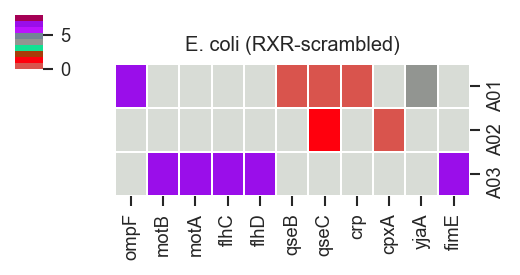

In [49]:
dset = 'A'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(muts.shape[1] / 3,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

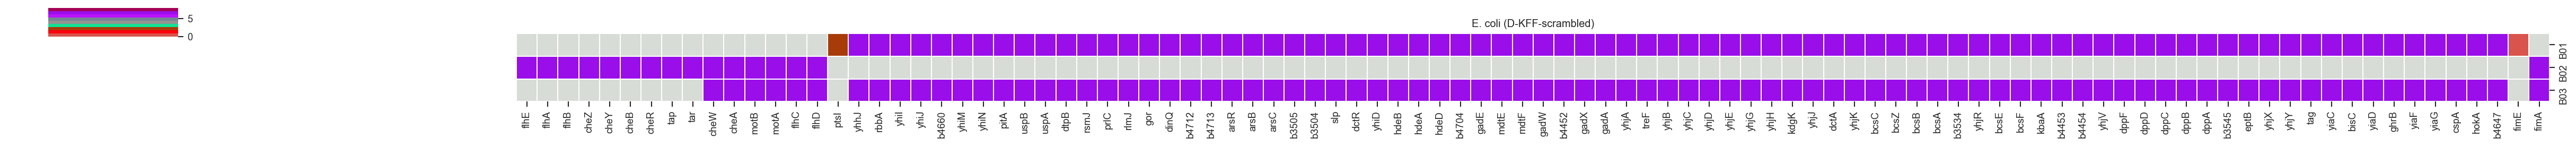

In [50]:
dset = 'B'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(muts.shape[1] / 3,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

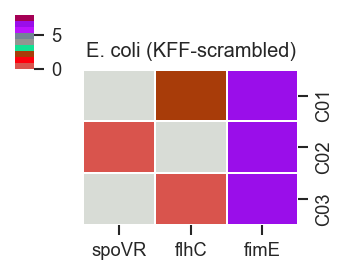

In [51]:
dset = 'C'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(2.5,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

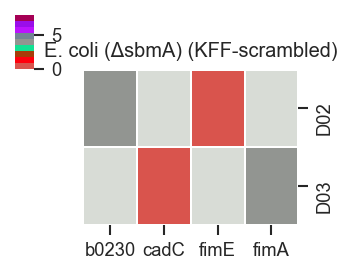

In [52]:
dset = 'D'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(2.5,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

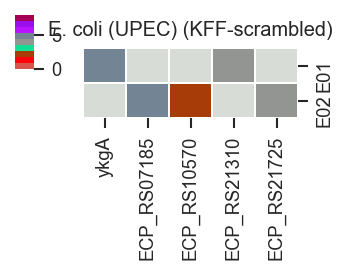

In [53]:
dset = 'E'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(2.5,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

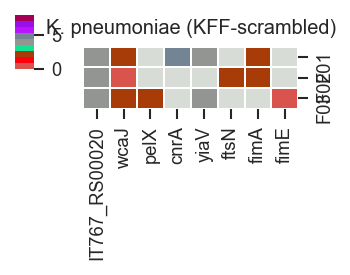

In [54]:
dset = 'F'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(2.5,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

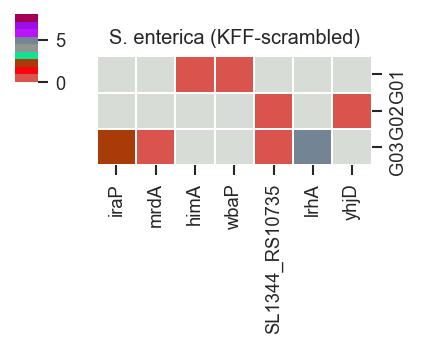

In [55]:
dset = 'G'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(3,
                        2.5),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

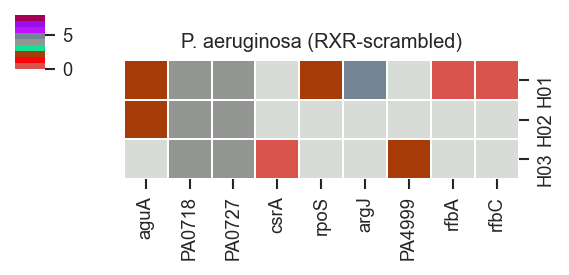

In [56]:
dset = 'H'
muts = m[m['set'] == dset]
aso, species = tags[dset]

muts = muts.sort_values(['chrom', 'locus_pos']
                       ).pivot_table(index='sample', columns=['chrom', 'locus_pos', 'og'],
                                     values='ntype', aggfunc=pick_mtype
                       ).T.reset_index().drop(columns=['chrom',
                                                       'locus_pos']).set_index('og').T
muts = muts.fillna(-1)

cm = sns.clustermap(muts,
               cmap=cmap, 
               vmin=0, vmax=8,
               row_cluster=False,
               col_cluster=False,
               figsize=(4,
                        2),
               linewidths=0.1,
               cbar=True);

cm.ax_heatmap.set_ylabel('')
cm.ax_heatmap.set_xlabel('')
cm.ax_heatmap.set_title(f"{species} ({aso})")
plt.savefig(f'matrix_cm_nc_{dset}.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

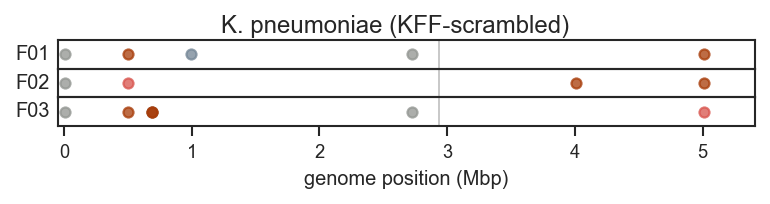

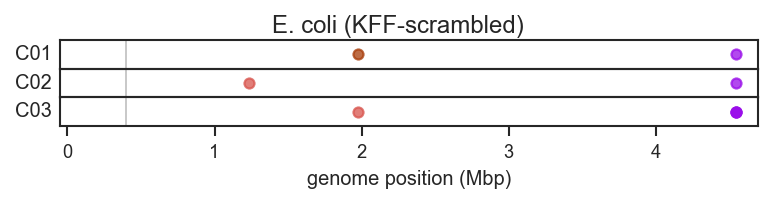

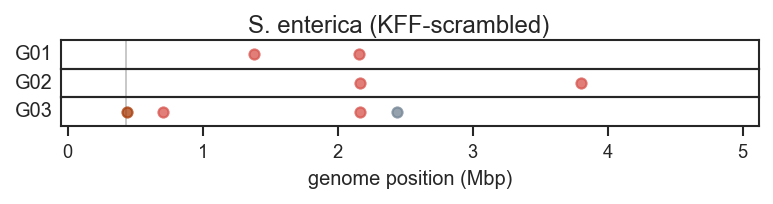

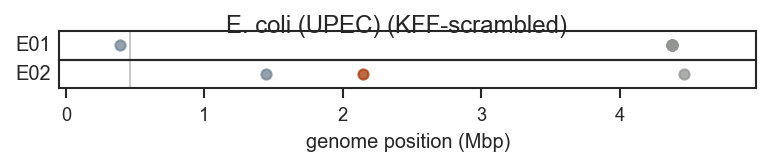

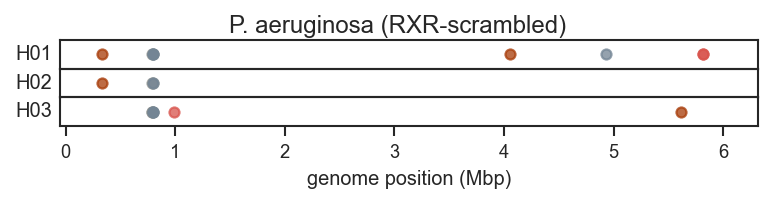

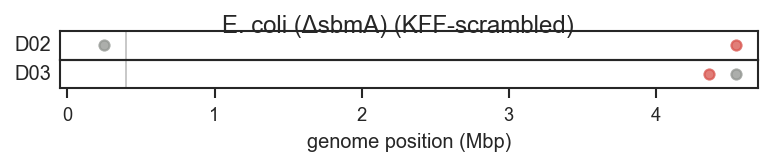

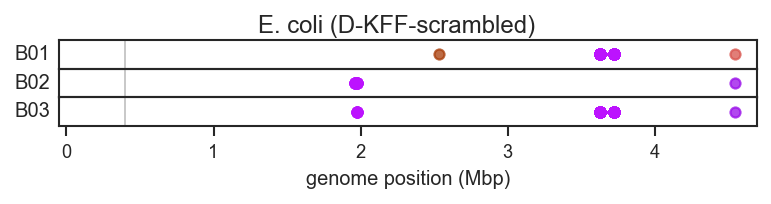

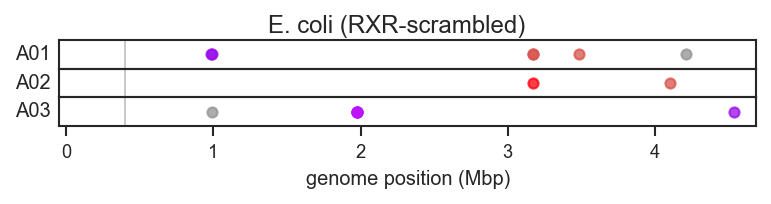

In [57]:
for dset in m['set'].unique():
    muts = m[m['set'] == dset]
    aso, species = tags[dset]
    
    fig, axes = plt.subplots(muts['sample'].unique().shape[0], 1, figsize=(6, muts['sample'].unique().shape[0] * 0.25))
    
    for i, (ax, sample) in enumerate(zip(axes.flatten(), sorted(muts['sample'].unique()))):
        for mt, ps, pe in muts[muts['sample'] == sample][['ntype', 'position_start', 'position_end']].values:
            ax.plot([int(ps) / 1_000_000, int(pe) / 1_000_000],
                     [0, 0],
                     'o-',
                     color=cmap(mt),
                     alpha=0.5)
    
        ax.set_xlim(-0.05, (glen[species] / 1_000_000) + 0.05)
        # ax.set_xlim(0.392, 0.4015)
        if species in dsbma:
            p1, p2 = dsbma[species]
            ax.fill_between([p1, p2], -1, 1,
                            color='grey', alpha=0.5)
        # if dset == 'R':
        #     p1, p2 = drpsh[species]
        #     ax.fill_between([p1, p2], -1, 1,
        #                     color='blue', alpha=0.5)
        # elif species in dacpp:
        #     p1, p2 = dacpp[species]
        #     ax.fill_between([p1, p2], -1, 1,
        #                     color='blue', alpha=0.5)
        ax.set_ylim(-0.01, 0.01)
        ax.set_ylabel(sample, rotation=0, ha='right', va='center')
        ax.set_yticks([])
        if i+1 != muts['sample'].unique().shape[0]:
            ax.set_xticks([])
        else:
            ax.set_xlabel('genome position (Mbp)')
    
    plt.subplots_adjust(hspace=0)
    plt.suptitle(f"{species} ({aso})", y=1.1)
    plt.savefig(f'mutations_nc_{dset}.svg',
                dpi=300, bbox_inches='tight',
                transparent=True)
    plt.savefig(f'mutations_nc_{dset}.png',
                dpi=300, bbox_inches='tight',
                transparent=True)